#  프로젝트 1의 회귀모델 예측정확도가 기준 이상 높게 나왔는가?

In [87]:
from sklearn.datasets import load_diabetes
data = load_diabetes()
df_X = data.data
df_y = data.target

In [88]:
import numpy as np
X = np.array(df_X)
print(type(X), X.dtype)

<class 'numpy.ndarray'> float64


In [89]:
y=np.array(df_y)
print(type(y), y.dtype)

<class 'numpy.ndarray'> float64


In [90]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(353, 10) (353,)
(89, 10) (89,)


In [91]:
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

print(len(W))

10


In [92]:
def model(X, W, b):
    predictions = 0
    for i in range(len(W)):
        predictions += X[:, i] * W[i]
    predictions += b
    return predictions

In [93]:
def MSE(a, b):
    mse = ((a-b) ** 2).mean()
    return mse

In [94]:
def loss(X, W, b, y):
    predictions = model(X, W, b)
    L = MSE(predictions, y)
    return L

In [95]:
def gradient(X, W, b, y):
    N = len(y)

    y_pred = model(X, W, b)

    dW = 1/N * 2 * X.T.dot(y_pred - y)

    db = 2 * (y_pred - y).mean()
    return dW, db

In [111]:
LEARNING_RATE = 0.01

In [112]:
%%timeit -n 1 -r 1
global W, b

losses = []

for i in range(1, 100001):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 5000 == 0:
        print('Iteration %d : Loss %0.4f' % (i, L))

Iteration 5000 : Loss 2890.8439
Iteration 10000 : Loss 2890.7507
Iteration 15000 : Loss 2890.6579
Iteration 20000 : Loss 2890.5655
Iteration 25000 : Loss 2890.4734
Iteration 30000 : Loss 2890.3818
Iteration 35000 : Loss 2890.2906
Iteration 40000 : Loss 2890.1997
Iteration 45000 : Loss 2890.1092
Iteration 50000 : Loss 2890.0191
Iteration 55000 : Loss 2889.9294
Iteration 60000 : Loss 2889.8401
Iteration 65000 : Loss 2889.7511
Iteration 70000 : Loss 2889.6625
Iteration 75000 : Loss 2889.5743
Iteration 80000 : Loss 2889.4865
Iteration 85000 : Loss 2889.3990
Iteration 90000 : Loss 2889.3119
Iteration 95000 : Loss 2889.2252
Iteration 100000 : Loss 2889.1388
10.9 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [113]:
prediction = model(X_test, W, b)
mse = loss(X_test, W, b, y_test)
mse

np.float64(2885.868365075627)

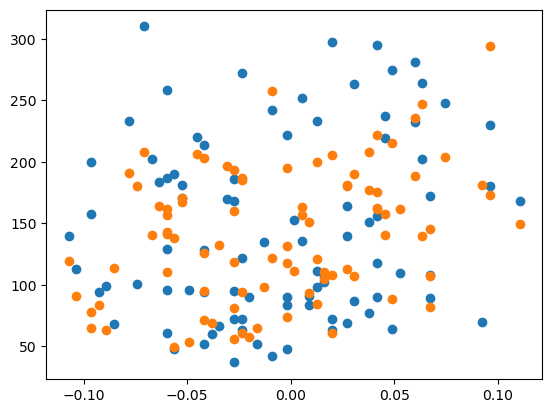

In [114]:
import matplotlib.pyplot as plt

plt.scatter(X_test[:, 0], y_test)
plt.scatter(X_test[:, 0], prediction)
plt.show()

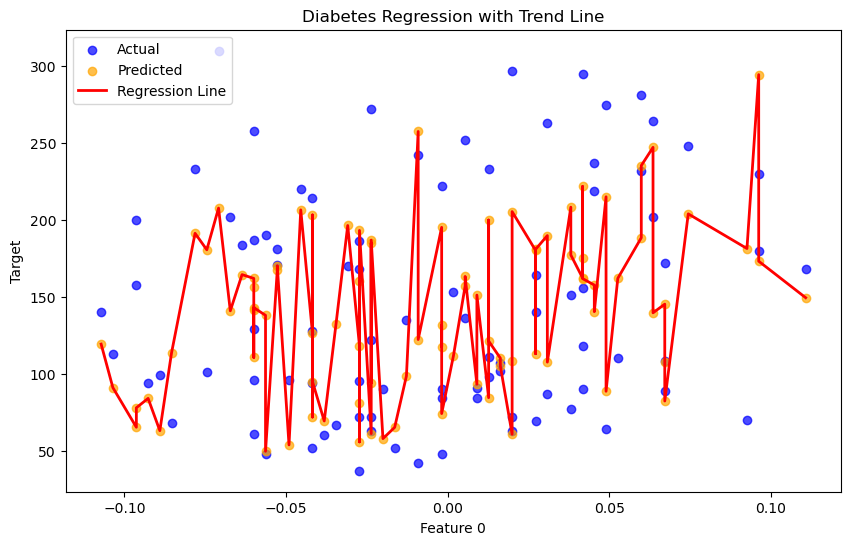

In [115]:
import matplotlib.pyplot as plt
import numpy as np

prediction = model(np.array(X_test), W, b)
feature = X_test[:, 0]  # 프로젝트1은 numpy 배열이라 iloc 필요없음

plt.figure(figsize=(10, 6))
plt.scatter(feature, y_test, label='Actual', color='blue', alpha=0.7)
plt.scatter(feature, prediction, label='Predicted', color='orange', alpha=0.7)

# 추세선
sort_idx = np.argsort(feature)
plt.plot(feature[sort_idx], prediction[sort_idx], 
         color='red', linewidth=2, label='Regression Line')

plt.xlabel('Feature 0')
plt.ylabel('Target')
plt.legend()
plt.title('Diabetes Regression with Trend Line')
plt.show()

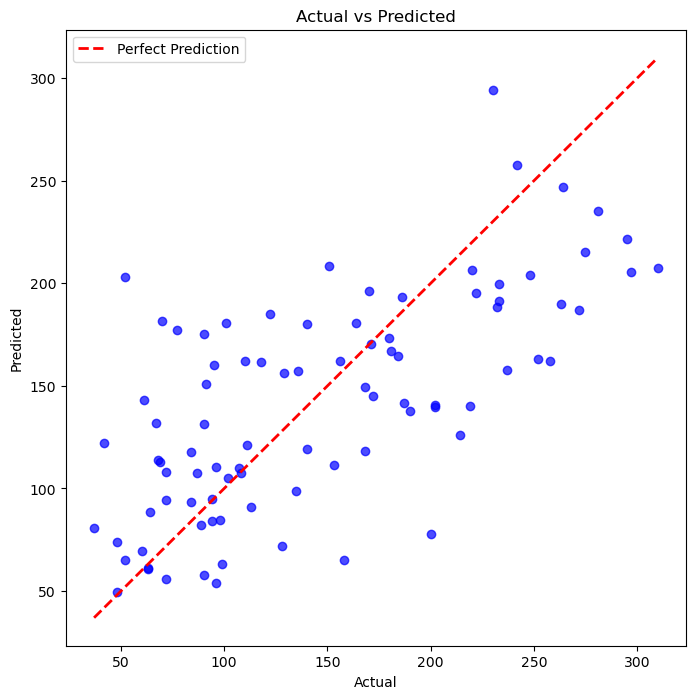

In [116]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, prediction, alpha=0.7, color='blue')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

In [117]:
# 정규화 - 숫자 범위를 통일
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# 다항 특성 - 직선 → 곡선으로 업그레이드
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_p = poly.fit_transform(X_train_s)
X_test_p = poly.transform(X_test_s)

In [118]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=500, random_state=42),
}

for name, m in models.items():
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    print(f"{name}: MSE = {mse:.1f}")

Ridge: MSE = 3077.4
Lasso: MSE = 2798.2
RandomForest: MSE = 2966.0
GradientBoosting: MSE = 3271.4


In [119]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    'n_estimators': [200, 500, 1000],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid, cv=5, scoring='neg_mean_squared_error'
)
grid.fit(X_train, y_train)

print("최적 설정:", grid.best_params_)
print("최적 MSE:", -grid.best_score_)

최적 설정: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
최적 MSE: 3499.9458557275875


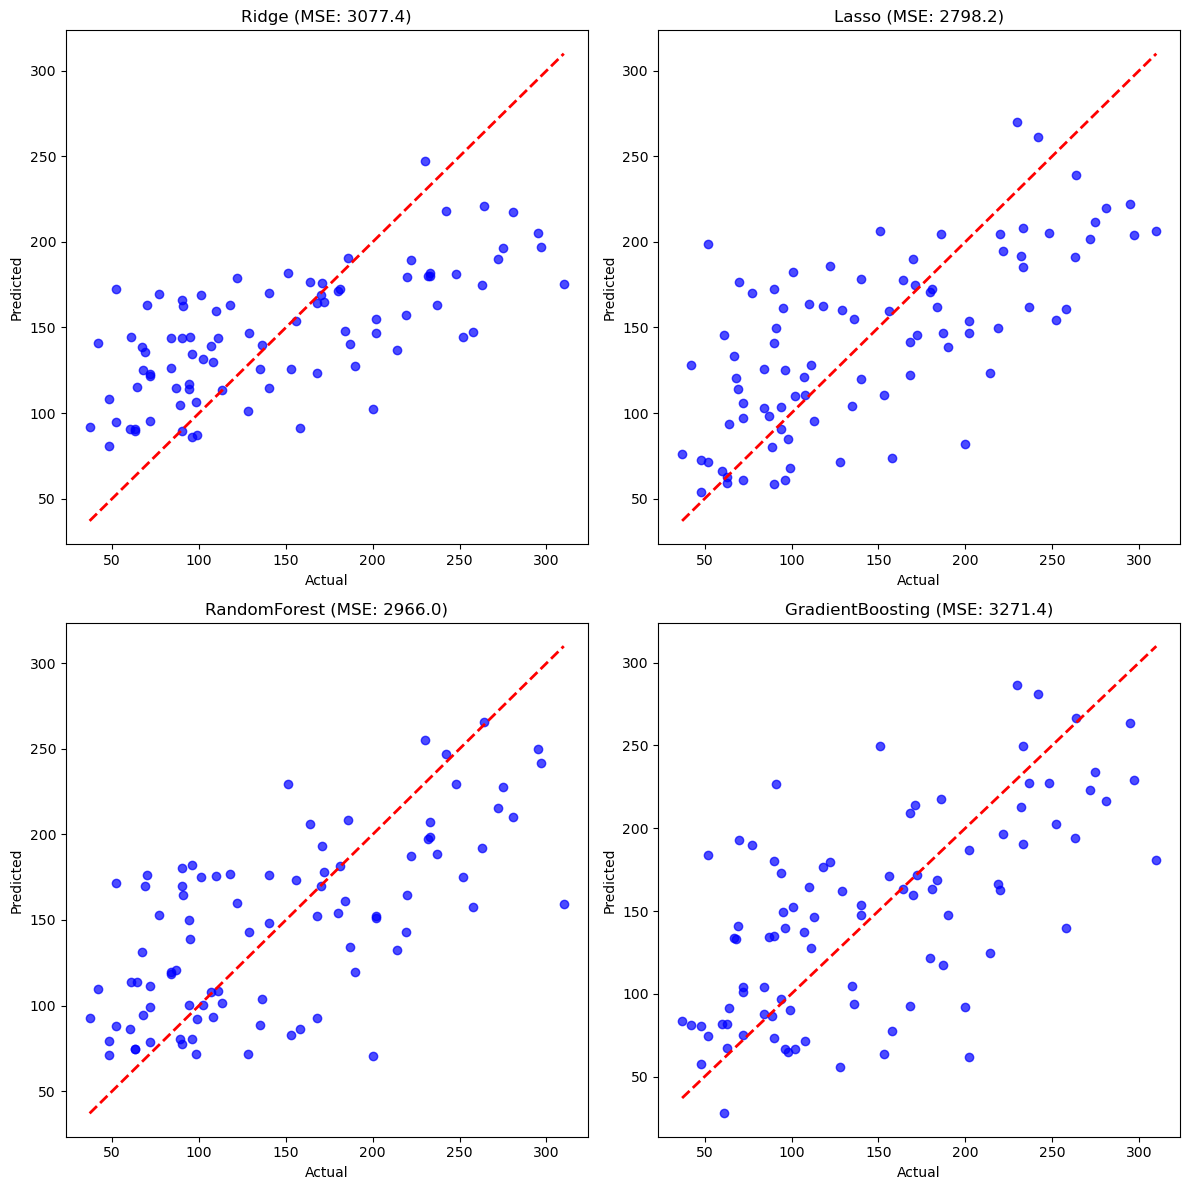

In [120]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for idx, (name, m) in enumerate(models.items()):
    pred = m.predict(X_test)
    mse = mean_squared_error(y_test, pred)
    
    axes[idx].scatter(y_test, pred, alpha=0.7, color='blue')
    axes[idx].plot([y_test.min(), y_test.max()], 
                   [y_test.min(), y_test.max()], 
                   'r--', linewidth=2)
    axes[idx].set_xlabel('Actual')
    axes[idx].set_ylabel('Predicted')
    axes[idx].set_title(f'{name} (MSE: {mse:.1f})')

plt.tight_layout()
plt.show()

# 프로젝트 2의 회귀모델 예측 정확도가 기준 이상 높게 나왔는가?

In [59]:
import pandas as pd

train = pd.read_csv("~/data/data/bike-sharing-demand/train.csv") 
train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [60]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['year'] = train['datetime'].dt.year
train['month'] = train['datetime'].dt.month
train['day'] = train['datetime'].dt.day
train['hour'] = train['datetime'].dt.hour
train['minute'] = train['datetime'].dt.minute
train['second'] = train['datetime'].dt.second

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  minute      10886 non-

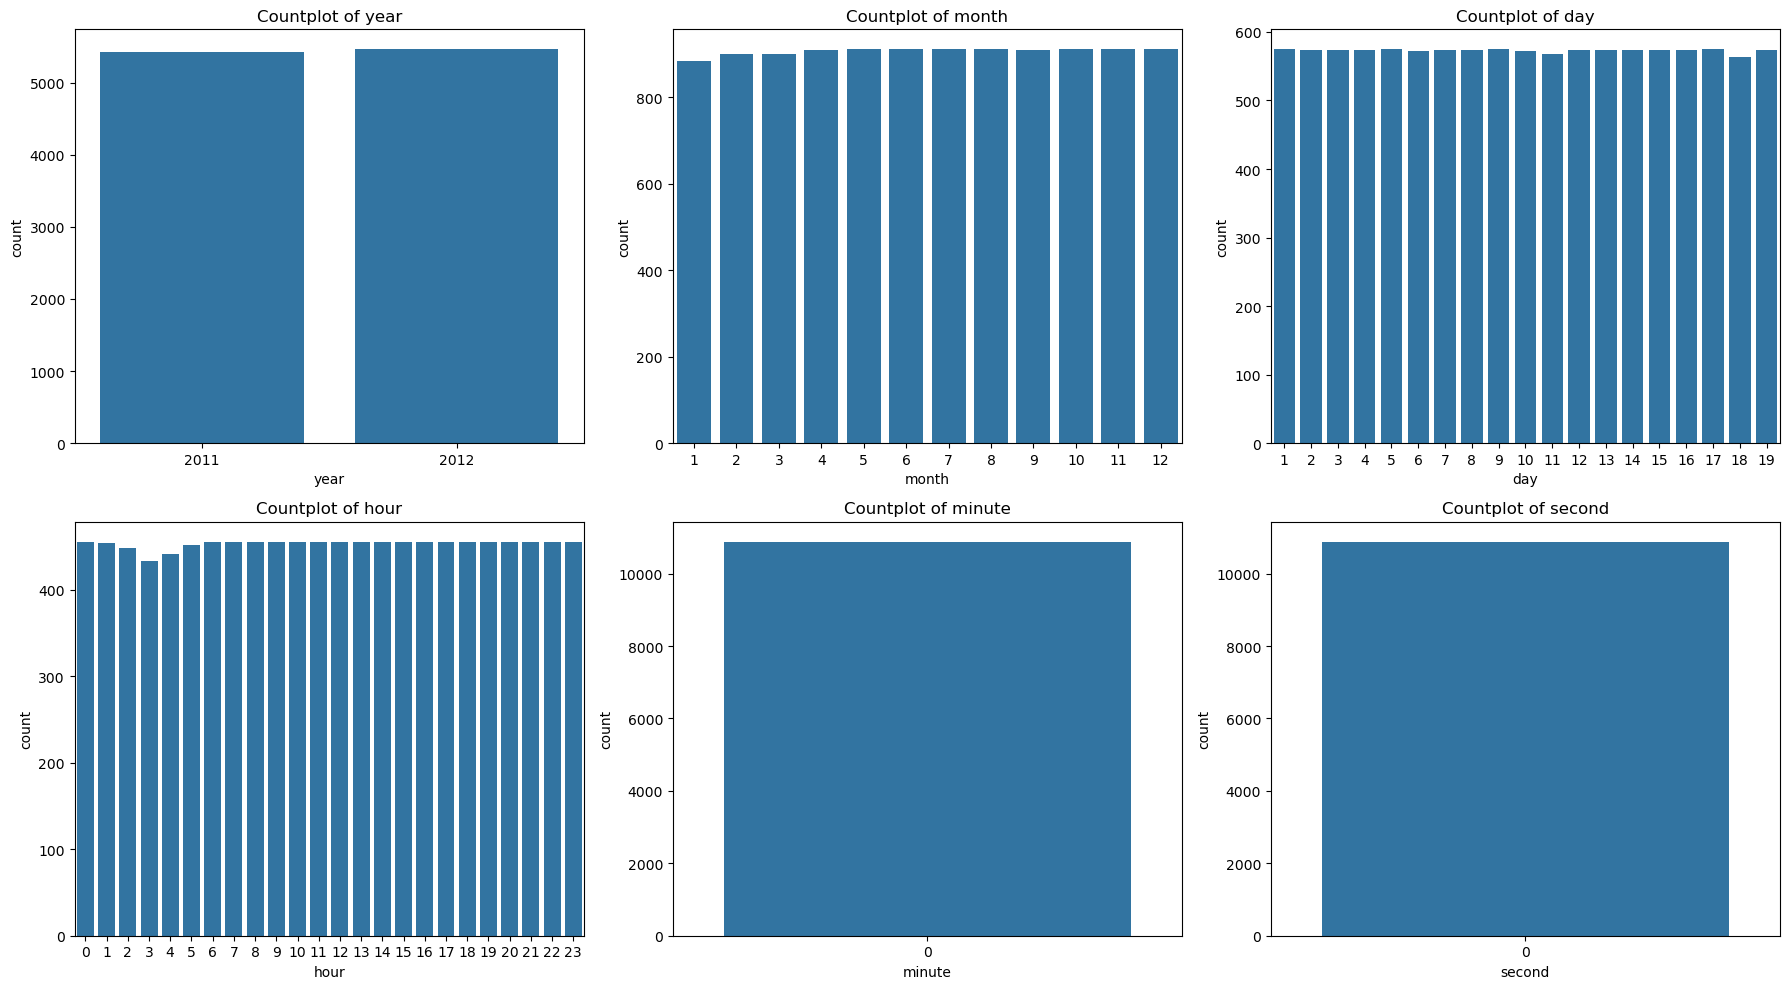

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(2, 3, figsize=(18, 10))
cols = ['year', 'month', 'day', 'hour', 'minute', 'second']
for ax, col in zip(axs.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(f'Countplot of {col}')
plt.tight_layout()
plt.show()

In [74]:
features = ['season', 'holiday', 'workingday', 'weather', 
            'temp', 'atemp', 'humidity', 'windspeed',
            'year', 'month', 'day', 'hour']
X = train[features]
y = train['count']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [75]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [76]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("MSE:", mse)
print("RMSE:", rmse)

MSE: 1786.3570818296603
RMSE: 42.26531771830966


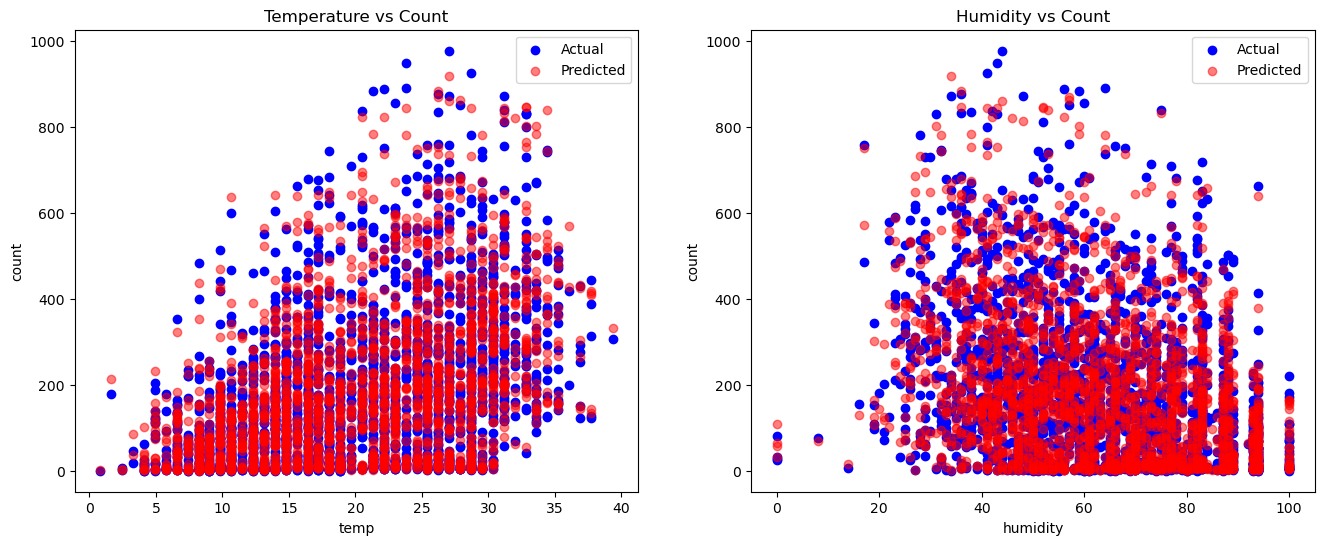

In [77]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# temp vs count 시각화
axs[0].scatter(X_test['temp'], y_test, color='blue', label='Actual')
axs[0].scatter(X_test['temp'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[0].set_xlabel('temp')
axs[0].set_ylabel('count')
axs[0].set_title('Temperature vs Count')
axs[0].legend()

# humidity vs count 시각화
axs[1].scatter(X_test['humidity'], y_test, color='blue', label='Actual')
axs[1].scatter(X_test['humidity'], y_pred, color='red', label='Predicted', alpha=0.5)
axs[1].set_xlabel('humidity')
axs[1].set_ylabel('count')
axs[1].set_title('Humidity vs Count')
axs[1].legend()

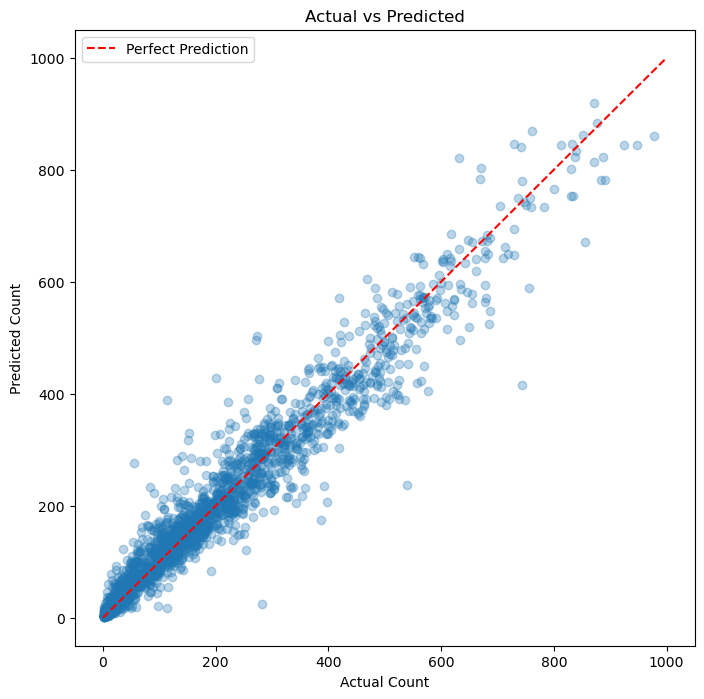

In [78]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([0, 1000], [0, 1000], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

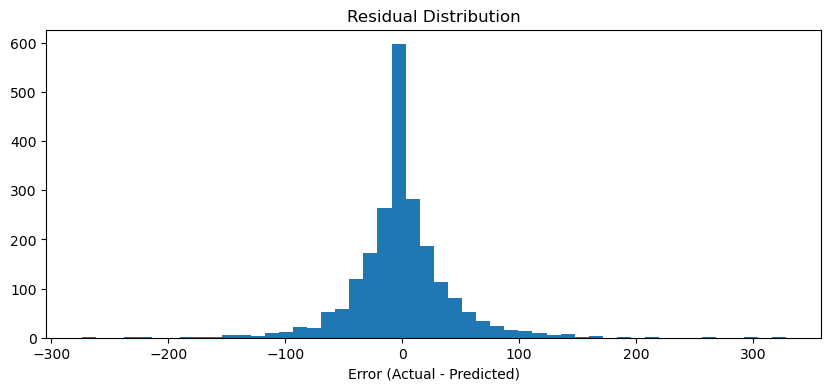

In [79]:
residuals = y_test - y_pred
plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=50)
plt.xlabel('Error (Actual - Predicted)')
plt.title('Residual Distribution')
plt.show()

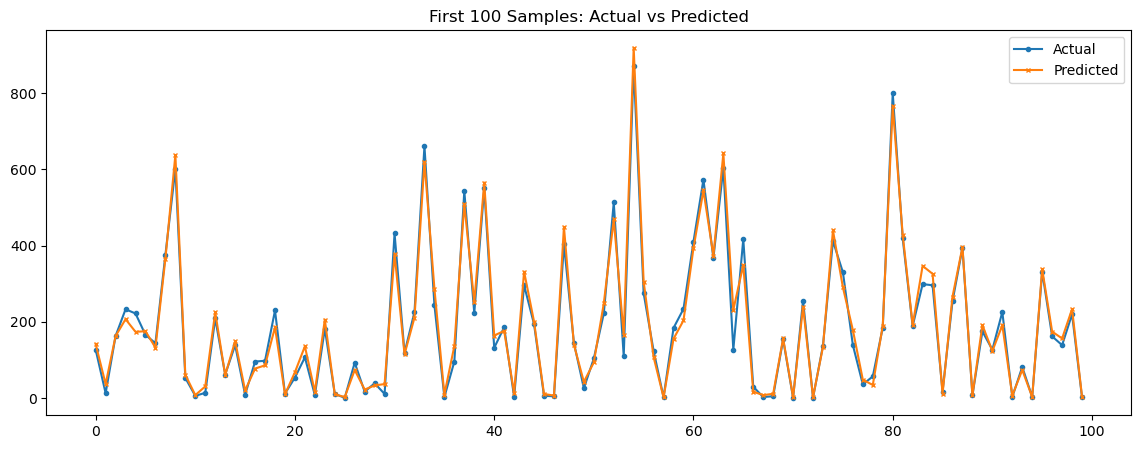

In [80]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:100], label='Actual', marker='o', markersize=3)
plt.plot(y_pred[:100], label='Predicted', marker='x', markersize=3)
plt.legend()
plt.title('First 100 Samples: Actual vs Predicted')
plt.show()